# Basic Setting

### Library

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

### Random State

In [124]:
SEED = 42

# Data Collection

### Get data from url

In [125]:
data_url = 'https://raw.githubusercontent.com/20161609/data_box/refs/heads/main/penguins.csv'
df = pd.read_csv(data_url)
df.shape

(344, 7)

In [126]:
df.head()

,Species,Island,Culmen Length(mm),Culmen Depth(mm),Flipper Length(mm),Body Mass(g),Sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


### Column name processing

In [127]:
def clean_column_names(col):
  # Change to lowercase and remove spaces and special characters ('_', '(', ')')
  col = col.strip()
  col = col.lower()
  col = col.replace(' ', '_')
  col = col.replace('(', '')
  col = col.replace(')', '')
  return col

df.columns = [clean_column_names(col) for col in df.columns]
df.head()

,species,island,culmen_lengthmm,culmen_depthmm,flipper_lengthmm,body_massg,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   species           344 non-null    object 
 1   island            344 non-null    object 
 2   culmen_lengthmm   342 non-null    float64
 3   culmen_depthmm    342 non-null    float64
 4   flipper_lengthmm  342 non-null    float64
 5   body_massg        342 non-null    float64
 6   sex               334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


# Data Proprecessing

### Missing values

In [129]:
# Handle missing values in numeric columns by filling with mean
numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        print(f"Filling missing values in numeric column '{col}' with mean.")
        df[col].fillna(df[col].mean(), inplace=True)

# Handle missing values in categorical columns by filling with mode
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
numerical_cols = df.select_dtypes(include=['number']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        print(f"Filling missing values in categorical column '{col}' with mode.")
        df[col].fillna(df[col].mode()[0], inplace=True)


Filling missing values in numeric column 'culmen_lengthmm' with mean.
Filling missing values in numeric column 'culmen_depthmm' with mean.
Filling missing values in numeric column 'flipper_lengthmm' with mean.
Filling missing values in numeric column 'body_massg' with mean.
Filling missing values in categorical column 'sex' with mode.


<ipython-input-129-5f323d6e3420>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
<ipython-input-129-5f323d6e3420>:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

### Encode categorical variables

In [130]:
# Convert categorical columns to numerical using Label Encoding
for col in categorical_cols:
  print(f"Encoding categorical column '{col}'.")

  le = LabelEncoder()
  # Convert to string before encoding
  df[col] = le.fit_transform(df[col].astype(str))

print("Missing values after preprocessing:")
print(df.isnull().sum())

Encoding categorical column 'species'.
Encoding categorical column 'island'.
Encoding categorical column 'sex'.
Missing values after preprocessing:
species             0
island              0
culmen_lengthmm     0
culmen_depthmm      0
flipper_lengthmm    0
body_massg          0
sex                 0
dtype: int64


### Duplication

In [131]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
final_rows = df.shape[0]
print(f"Removed {initial_rows - final_rows} duplicate rows.")

Removed 0 duplicate rows.


In [132]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
species,344.0,0.918605,0.893320,0.0,0.000,1.00,2.0,2.0
island,344.0,0.662791,0.726194,0.0,0.000,1.00,1.0,2.0
culmen_lengthmm,344.0,43.921930,5.443643,32.1,39.275,44.25,48.5,59.6
culmen_depthmm,344.0,17.151170,1.969027,13.1,15.600,17.30,18.7,21.5
flipper_lengthmm,344.0,200.915205,14.020657,172.0,190.000,197.00,213.0,231.0
body_massg,344.0,4201.754386,799.613058,2700.0,3550.000,4050.00,4750.0,6300.0
sex,344.0,1.514535,0.506308,0.0,1.000,2.00,2.0,2.0


# Data Preparation

### Show data histogram(Numeric values)

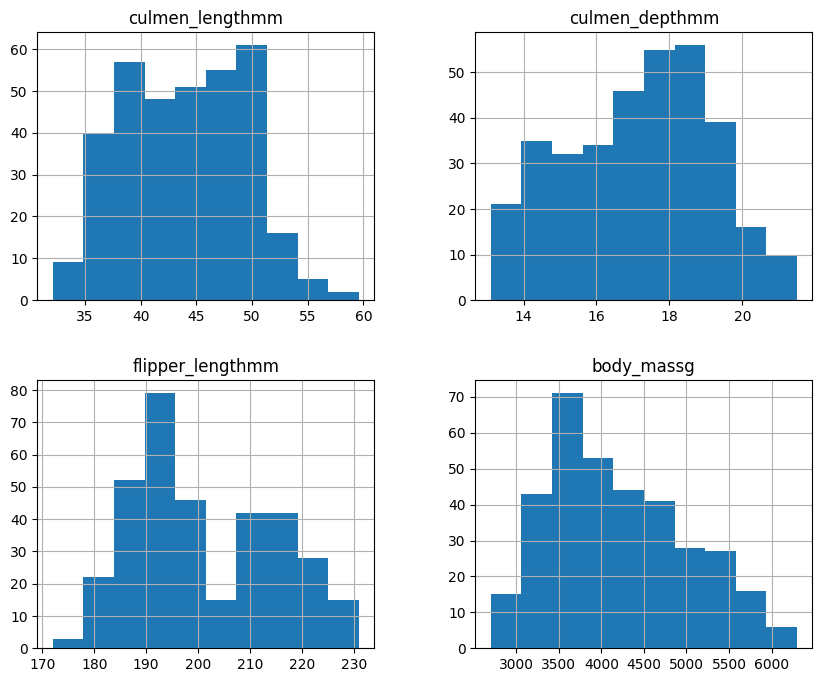

In [133]:
cols_num = df[numerical_cols]
cols_num

cols_num.hist(figsize=(10, 8))
plt.show()

### Box Plot

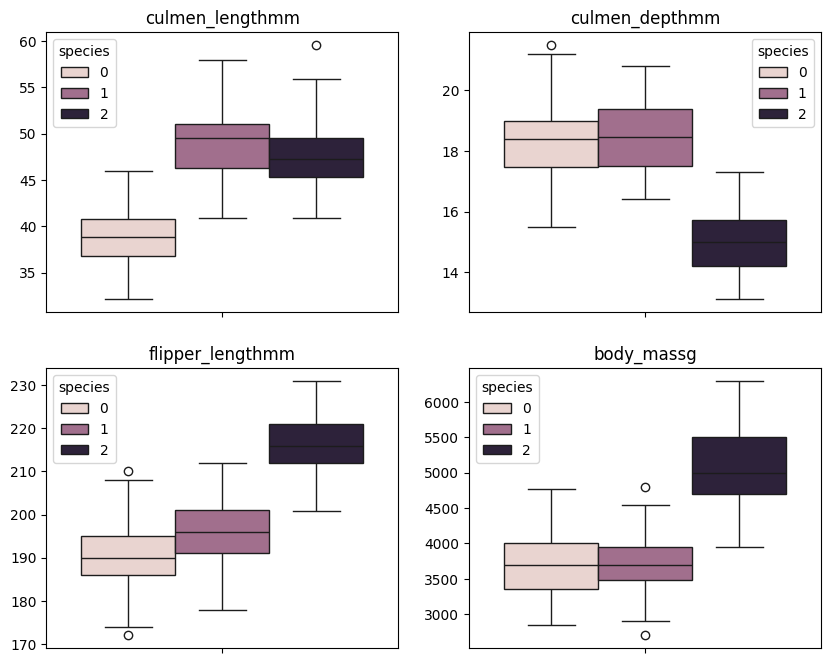

In [134]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()


for i, col in enumerate(cols_num.columns):
  sns.boxplot(y=col, data=cols_num, hue=df['species'], ax=axes[i])
  axes[i].set_xlabel(None)
  axes[i].set_ylabel(None)
  axes[i].set_title(col)

### Data split

In [135]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['species'])

train.shape, test.shape

((275, 7), (69, 7))

In [149]:
# sns.heatmap(train.isna())

In [138]:
X_train = train.drop('species', axis=1)
y_train = train['species']

X_train.shape, y_train.shape

((275, 6), (275,))

In [139]:
X_train.head()

,island,culmen_lengthmm,culmen_depthmm,flipper_lengthmm,body_massg,sex
98,1,33.1,16.1,178.0,2900.0,1
114,0,39.6,20.7,191.0,3900.0,1
118,2,35.7,17.0,189.0,3350.0,1
303,0,50.0,15.9,224.0,5350.0,2
343,0,49.9,16.1,213.0,5400.0,2


In [141]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_e = le.fit_transform(y_train)
y_train_e


array([0, 0, 0, 2, 2, 2, 0, 2, 1, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 2,
       0, 0, 2, 0, 0, 0, 2, 0, 1, 1, 0, 2, 0, 0, 2, 2, 0, 0, 2, 2, 2, 0,
       0, 2, 0, 0, 1, 2, 0, 1, 0, 2, 2, 2, 1, 0, 0, 1, 0, 2, 2, 0, 0, 1,
       2, 0, 0, 0, 1, 2, 1, 0, 2, 1, 0, 0, 2, 2, 2, 0, 0, 2, 0, 0, 2, 2,
       2, 0, 1, 2, 1, 2, 1, 1, 0, 0, 1, 1, 0, 0, 2, 0, 1, 0, 2, 2, 1, 2,
       1, 0, 1, 0, 1, 1, 2, 0, 0, 2, 2, 2, 2, 1, 2, 0, 2, 0, 0, 0, 0, 0,
       1, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 1, 1, 2, 2, 0, 0, 0, 0, 2, 2, 0,
       2, 0, 1, 2, 2, 0, 1, 2, 2, 2, 0, 0, 2, 0, 0, 2, 0, 2, 0, 0, 0, 2,
       0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 0, 2, 2, 2,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 2, 0, 1,
       2, 0, 1, 0, 1, 2, 2, 2, 2, 1, 1, 1, 2, 1, 0, 1, 0, 0, 0, 1, 0, 2,
       0, 0, 2, 2, 0, 0, 1, 0, 1, 2, 1, 2, 2, 2, 0, 2, 2, 0, 2, 0, 2, 0,
       0, 0, 1, 2, 1, 0, 0, 2, 0, 0, 1])

In [142]:
from sklearn.preprocessing import RobustScaler

rs = RobustScaler()
X_train_s = rs.fit_transform(X_train)
X_train_s

array([[ 0.        , -1.25274725, -0.375     , -0.82608696, -0.94845361,
        -1.        ],
       [-1.        , -0.53846154,  1.0625    , -0.26086957, -0.12371134,
        -1.        ],
       [ 1.        , -0.96703297, -0.09375   , -0.34782609, -0.57731959,
        -1.        ],
       ...,
       [ 1.        , -0.18681319,  0.375     , -0.08695652,  0.16494845,
         0.        ],
       [ 1.        , -0.85714286,  0.46875   , -0.43478261, -0.20618557,
        -1.        ],
       [ 0.        ,  0.69230769,  0.53125   ,  0.56521739,  0.04123711,
         0.        ]])

In [143]:
print(X_train_s.shape, y_train.shape)
print(type(X_train_s), type(y_train_e))


(275, 6) (275,)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


# Tree Algorithm

In [144]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42, max_depth=3)
clf.fit(X_train_s, y_train_e)

DecisionTreeClassifier(max_depth=3, random_state=42)

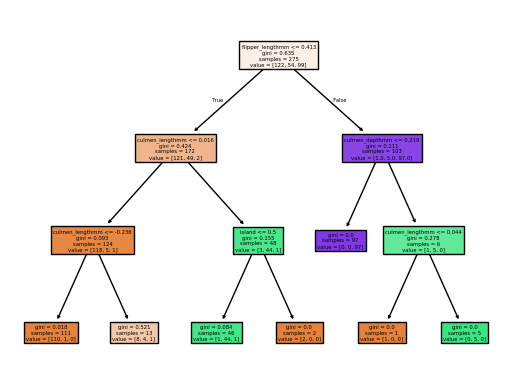

In [145]:
from sklearn.tree import plot_tree

plot_tree(clf, filled=True, feature_names=X_train.columns)
plt.show()

In [146]:
X_train.columns

Index(['island', 'culmen_lengthmm', 'culmen_depthmm', 'flipper_lengthmm',
       'body_massg', 'sex'],
      dtype='object')

In [147]:
clf.feature_importances_

array([0.02215126, 0.36017386, 0.06006589, 0.55760899, 0.        ,
       0.        ])

# Random Forest

In [148]:
from sklearn.ensemble import RandomForestClassifier

clf_r = RandomForestClassifier(n_estimators=100, random_state=42)
clf_r.fit(X_train_s, y_train_e)

RandomForestClassifier(random_state=42)